Processing 73 rows.
tensor([[-0.9208, -1.1433, -0.7665,  ...,  0.3098,  0.1028,  0.0079],
        [-0.8544, -1.1352, -0.7584,  ...,  0.2564,  0.1018,  0.0374],
        [-0.9018, -1.1621, -0.7853,  ...,  0.3087,  0.1152, -0.0163],
        ...,
        [ 0.4670,  0.4670,  0.4670,  ...,  0.4670,  0.4670,  0.4670],
        [ 0.4670,  0.4670,  0.4670,  ...,  0.4670,  0.4670,  0.4670],
        [ 0.4670,  0.4670,  0.4670,  ...,  0.4670,  0.4670,  0.4670]])


/Users/oscar/Desktop/Projects/birdcleff-2026/venv/lib/python3.11/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


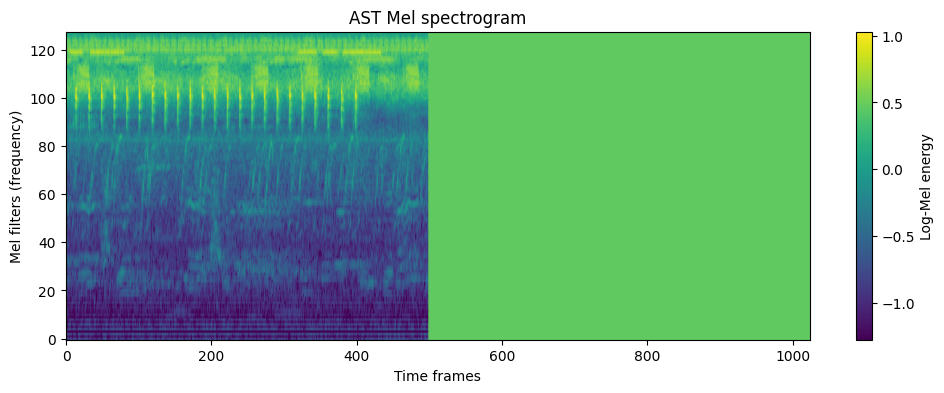

In [ ]:
import matplotlib.pyplot as plt

from src.data_manager import DataManager
from src.config import Config


config = Config()
data_manager = DataManager(config)

for batch in data_manager:
    spectrogram = batch['input_values'][0]
    spectrogram = spectrogram.T.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Log-Mel energy')
    plt.title('AST Mel spectrogram')
    plt.xlabel('Time frames')
    plt.ylabel('Mel filters (frequency)')
    plt.show()
    break

In [2]:
import torch

from transformers import ASTForAudioClassification

from src.config import Config
from src.data_manager import DataManager

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
config = Config()
data_manager = DataManager(config)
checkpoint_path = 'data/checkpoints/checkpoint-15'
model = ASTForAudioClassification.from_pretrained(checkpoint_path)
model.eval()
model.to(device)  # type: ignore

filename = 'BC2026_Train_0004_S08_20250607_070007'

with torch.no_grad():
    start_seconds, end_seconds = 50.0, 55.0
    input = data_manager.get_inference_input(
        f'./data/train_soundscapes/{filename}.ogg',
        start_seconds,
        end_seconds
    ).to(device)
    logits = model(input).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)


print(f'row_id={filename}_{int(end_seconds)}')
probs = probs[-1, :]
for idx in range(len(probs)):
    print(f'{data_manager.id_to_label[idx]}={probs[idx]}')

Processing 73 rows.


/Users/oscar/Desktop/Projects/birdcleff-2026/venv/lib/python3.11/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

row_id=BC2026_Train_0004_S08_20250607_070007_55
22961=0.003916136920452118
22973=0.2814297080039978
23158=0.006799530237913132
24279=0.001901718438602984
24321=0.009760845452547073
47144=0.002469988539814949
517063=0.09712975472211838
555146=0.021114613860845566
65380=0.564431369304657
66971=0.007234880700707436
bunibi1=0.0038115722127258778
